# Climate scenarios

## 5.1 Description

The model will be run for the future under various Shared Socioeconomic Pathway Scenarios (SSP’s). These scenarios represent different possible future outcomes depending on the increase in trapped radiation in the atmosphere. CMIP6 provides 5 scenarios ranging from SSP119 to SSP585. These outer extreme scenarios were not included in this study because recent emission trends and climate policy indicate these scenarios have become less plausible (van Vuuren et al., 2026). For a description of the scenarios used in this study see table 3. 

*Table 5.1: Table 3: description of various CMIP6 SSP’s from 2025-2099 (Government of Canada, 2019).*

| **Scenarios**  | **Description**                    | **Global $\Delta$T$^{\circ}$C** | Period  |
|----------------|------------------------------------|---------------------------------|---------|
| SSP126         | “Middle of the road”: Trends do not shift from historical  patterns                         | 1,8      | 2025 - 2099 |
| SSP245         | “A rocky road”: Low international priority in addressing environmental concerns. High challenges to mitigation and adaptation, resurgent nationalism, slow economic growth.                        | 2,7                             | 2025 - 2099 |
| SSP370         | “A road divided”: Large gap between high and low tech economies, widening global disparities, diverse investment in fossil fuels and renewable energy sources.                        | 3,7                             | 2025 - 2099 |

## 5.2 CMIP6 low flow comparison/validation

To see if the CMIP6 dataset produces realistic model outcomes, historical low flow data will be compared to observed and ERA5 low flow data over a 25 year period from 1989-2014. It should be noted that CMIP6 is not a reanalysis model like ERA5 but a climate model, meaning it is not expected to reproduce the timing of peaks or wet and dry years precisely. Instead, model outcomes are expected to statistically match observed and ERA5 outcomes over a longer time period. Figure 11 shows the cumulative distribution of low flow days for this 25 year period. 

To match CMIP6 data to ERA5, quantile delta mapping may be applied. This is a correction method to align the distribution of climate model outputs with observational data and thus minimising distributional biases. This has been applied on forcing inputs using the adjust function from python module cmethods and discharge outputs using interp1d from scipy.interpolate. However, both did not yield better results and were therefore not used.


### Startup & Imports

In [41]:
# General python
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from scipy.interpolate import interp1d

# Niceties
from rich import print

In [42]:
# General eWaterCycle
import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

In [43]:
# Defining things

basin_size = 132572
q_critical = 500

In [44]:
# Choosing time period

start_year = 1995
end_year = 2014

validation_start = f"{start_year}-01-01T00:00:00Z"
validation_end = f"{end_year}-12-31T00:00:00Z"

# Choose CMIP Scenario: 
Scenario = "historical"    # Options: historical, ssp119, ssp126, ssp245, ssp,370, ssp585

# Attach colours to scenarios to make plotting easier 
colours = {"historical": "tab:blue", "ssp126": "green", "ssp245": "orange", "ssp370": "red"}

In [45]:
# # Create pathways for forcings

forcing_path_ERA5 = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" /  "Workyard" / "forcings" / "ERA5" / f"ERA5-{start_year}-{end_year}"

forcing_path_CMIP = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "forcings" / "CMIP6" / Scenario / f"CMIP6-{start_year}-{end_year}"

forcing_path_QDM = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "forcings" / "CMIP6" / Scenario / f"CMIP6-QDM-{start_year}-{end_year}"

discharge_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" /  "Workyard" / "07DA001_discharge_daily_withoutmissing.csv"

shape_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" /  "Workyard" / "Shapefiles" / "07DA001_basin.shp"

hbv_config = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" /  "Workyard" / "hbv_config"
hbv_config.mkdir(parents=True, exist_ok=True)

In [46]:
# Load CSV discharge 07DA001

q_obs = pd.read_csv(discharge_file, skiprows=1)
q_obs = q_obs[["Date", "Value"]].copy()
q_obs["Date"] = pd.to_datetime(q_obs["Date"])
q_obs = q_obs.rename(columns={"Value": "discharge_m3s"})

In [47]:
# Define time period
validation_start_date = pd.to_datetime(validation_start.replace("Z", ""))
validation_end_date = pd.to_datetime(validation_end.replace("Z", ""))

# Skip 1 year for filling storages
evaluation_start = pd.to_datetime(f"{validation_start_date.year + 1}-01-01")

# Align q_obs to relevant dates
q_obs = q_obs[(q_obs["Date"] >= validation_start_date) & (q_obs["Date"] <= validation_end_date)]
observed_output = pd.Series(data=q_obs["discharge_m3s"].to_numpy(), name="Observed discharge", index=q_obs["Date"])

In [48]:
# Load data
ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=forcing_path_ERA5)

CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=forcing_path_CMIP)

In [49]:
# Load calibration constants

par_ensemble = [
    [6.279135, 0.4808243, 174.127749, 1.9527195, 0.3305087, 6.19919, 0.0768362, 0.004366398, 0.4076606],
    [7.35776, 0.432509, 192.67085, 1.66088, 0.289296, 5.323766, 0.037268, 0.004399, 1.146504],
    [7.9355, 0.4593, 219.6962, 1.72624, 0.26391, 5.810765, 0.04804, 0.0155065, 0.76857],
    [5.5464, 0.46496, 187.8548, 1.82803, 0.440628, 6.29496, 0.062766, 0.033095, 0.80392],
   [7.23868, 0.47495, 181.82012, 1.8232, 0.4884032, 5.546412, 0.0449439, 0.00231717, 1.25052]]


par_names = ["Imax",         # Maximum interception storage
               "Ce",         # Evaporation correction factor
               "Sumax",      # Maximum soil moisture storage
               "Beta",       # Soil runoff parameter
               "Pmax",       # Maximum percolation rate
               "Tlag",       # Time lag
               "Kf",         # Fast reservoir recession coefficient
               "Ks",         # Slow reservoir recession coefficient
               "FM"]          # Snowmelt factor

In [50]:
# Storages

#               Si,  Su, Sf, Ss, Sp
s_0 = np.array([0,  100,  0,  5,  0])

### Model setup

In [51]:
def run_hbv(parameters, initial_storages, forcing):

    # Creating model object
    model = ewatercycle.models.HBV(forcing=forcing)

    # Creating config file
    config_file, _ = model.setup(
        parameters=parameters,
        initial_storages=initial_storages,
        cfg_dir=hbv_config)

    # Initialising model
    model.initialize(config_file)

    # Define & update outputs
    Q_m = []
    time = []

    while model.time < model.end_time:
        model.update()
        Q_m.append(model.get_value("Q")[0])
        time.append(pd.Timestamp(model.time_as_datetime))

    model.finalize()

    # Convert mm/day to m3/s
    model_output_mmday = pd.Series(
        data=Q_m,
        index=time,
        name="Modelled discharge")

    model_output_m3s = model_output_mmday * basin_size * 1000 / 86400

    return model_output_m3s

### Running model

In [52]:
def run_hbv_ensemble(par_ensemble, initial_storages, forcing):

    # Define amount of parameter sets
    N = len(par_ensemble)
    
    # Create dataframe to append data to & add column for observed data
    ensemble_data = pd.DataFrame()

    for i in range(N):

        # Run HBV model for the parameter sets 
        simulated = run_hbv(
            parameters=par_ensemble[i],
            initial_storages=initial_storages,
            forcing=forcing)

        # Filter data by day only, not by day & time to prevent alignment issues
        simulated_daily = simulated

        simulated_daily.index = pd.to_datetime(simulated_daily.index).tz_localize(None).normalize()
        simulated_daily.name = f"Set {i+1}"
         
        # Append new column for every parameter set results
        ensemble_data[f"Set {i+1}"] = simulated

    # Filter observed data by day
    observed_daily = observed_output
    observed_daily.index = pd.to_datetime(observed_daily.index).tz_localize(None).normalize()

    # Add mean of all sets
    ensemble_data["Mean"] = ensemble_data.mean(axis=1)
    ensemble_data['Observed discharge'] = observed_daily

    return ensemble_data

In [53]:
ensemble_data_ERA5 = run_hbv_ensemble(
    par_ensemble=par_ensemble,
    initial_storages=s_0,
    forcing=ERA5_forcing)

ensemble_data_CMIP = run_hbv_ensemble(
    par_ensemble=par_ensemble,
    initial_storages=s_0,
    forcing=CMIP_forcing)


### Lowflow calculation

In [54]:
def lowflow_counter_ensemble(ensemble_data, start_date, end_date):
    
    lowflow_days = []

    years = list(range(start_date.year, end_date.year + 1))

    for i in range(len(years)):
    
        year = years[i]
    
        # Define start and end month-day
        year_start = pd.to_datetime(f"{year}-05-18")
        year_end = pd.to_datetime(f"{year}-10-17")
    
        year_data = ensemble_data[
            (ensemble_data.index >= year_start) &
            (ensemble_data.index <= year_end)]

        # Set zeros to count from
        observed_lowflow_days = 0
        modelled_lowflow_days = []
        modelmean_lowflow_days = 0

        # Count observed lowflow days
        for j in range(len(year_data)):
            observed_q = year_data.iloc[j]["Observed discharge"]

            if observed_q < q_critical:
                observed_lowflow_days += 1

        # Count model mean lowflow days
        for j in range(len(year_data)):
            modelmean_q = year_data.iloc[j]["Mean"]

            if modelmean_q < q_critical:
                modelmean_lowflow_days += 1

        # Count modelled lowflow days
        for j in range(len(par_ensemble)):
            set_lowflow_days = 0

            for k in range(len(year_data)):
                set_q = year_data.iloc[k][f"Set {j+1}"]

                if set_q < q_critical:
                    set_lowflow_days += 1

            modelled_lowflow_days.append(set_lowflow_days)

        setavg_lowflow_days = np.mean(modelled_lowflow_days)
        
        lowflow_days.append({
            "year": year,
            "observed": observed_lowflow_days,
            "modelmean": modelmean_lowflow_days,
            "set_1": modelled_lowflow_days[0],
            "set_2": modelled_lowflow_days[1],
            "set_3": modelled_lowflow_days[2],
            "set_4": modelled_lowflow_days[3],
            "set_5": modelled_lowflow_days[4],
            "set_avg": np.round(setavg_lowflow_days)})

    lowflow_days = pd.DataFrame(lowflow_days)

    days_sum = lowflow_days[["observed", "modelmean", "set_1", "set_2", "set_3", "set_4", "set_5", "set_avg"]].sum()

    return lowflow_days

In [55]:
lowflow_ERA5 = lowflow_counter_ensemble(
    ensemble_data=ensemble_data_ERA5,
    start_date=evaluation_start,
    end_date=validation_end_date)

lowflow_CMIP = lowflow_counter_ensemble(
    ensemble_data=ensemble_data_CMIP,
    start_date=evaluation_start,
    end_date=validation_end_date)

### CDF Calculation

In [56]:
def rank(lowflow_ERA5, lowflow_CMIP):

    # Combine tables
    rank_table = pd.DataFrame({
        "Observed": np.sort(lowflow_ERA5["observed"]),
        "ERA5": np.sort(lowflow_ERA5["set_avg"]),
        "CMIP6": np.sort(lowflow_CMIP["set_avg"]),})
    
    rank_table.insert(0, "rank", range(1, len(rank_table) + 1))

    return rank_table

In [57]:
rank_table = rank(lowflow_ERA5, lowflow_CMIP)

In [58]:
def plot_cumsum(rank_table):

    plt.figure(figsize=(8, 5))

    # Plot cumsum for all columns, skipping rank column
    for i in range(1, len(rank_table.columns)):
        plt.plot(rank_table["rank"], rank_table[rank_table.columns[i]].cumsum(), marker="o", label=rank_table.columns[i])

    # Plotting
    plt.xlabel("Ranked years")
    plt.ylabel("Cumulative low flow days")
    plt.xticks(rank_table["rank"])
    plt.title("Cumulative annual low flow days")
    # plt.grid(True)
    plt.legend()
    plt.show()

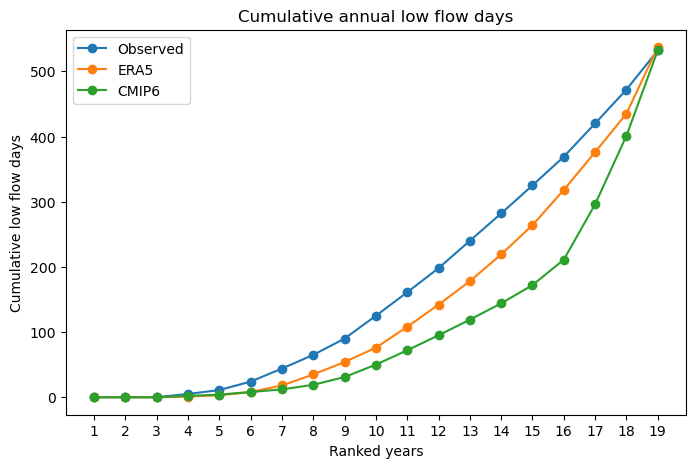

In [59]:
plot_cumsum(rank_table)

**Figure 11:** Cumulative distribution of low flow days between 1989-2014 for historical, ERA5 and CMIP6 data. 


Figure 11 shows a slight deviation in CMIP6 low flow days compared to the observed and ERA5 curves, particularly in the lower and higher ranked years. This suggests that CMIP6 may slightly overestimate extremes i.e. driest years appear drier and wettest years appear wetter. Despite this, CMIP6 follows the general curve trend reasonably well and precisely reproduces the total number of low flow days. The observed data shows 532 total low flow days over this period, ERA5 537 days and CMIP6 532 days. Future CMIP6 forcings are therefore considered suitable for analysing trends in low flow days over long periods although extreme years should be interpreted with caution. 